<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/00_Wikipedia_Pageviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wikipedia Pageviews (일별 조회수) — BTS / Squid Game / Elden Ring


> **학습목표 (전체(이 노트북))**
>
- Wikimedia Pageviews API로 **가입/키 없이** 일별 조회수 시계열을 수집한다.
- 결측/이상치/스파이크가 많은 ‘관심도 시계열’의 특성을 설명하고 기본 전처리를 수행한다.
- STL/ACF/정상성(ADF·KPSS)으로 구조를 진단하고, 간단한 베이스라인 예측을 만든다.


### 🧭 수업 맥락(주가 대신 ‘콘텐츠 관심도’)
- 주가처럼 ‘수치가 움직이는 이유’가 추상적인 데이터보다, **학생들이 아는 콘텐츠**(아티스트/드라마/게임)의 관심도는 반응이 훨씬 좋습니다.
- 위키 조회수는 이벤트(컴백, 수상, 넷플릭스 재공개, DLC 출시 등)가 있을 때 스파이크가 크게 나타나 **이상치/변화점/계절성** 논의에 적합합니다.


## 0) 데이터 설명: Wikimedia Pageviews API (가입/키 필요 없음)
**무엇을 주나?**
- 특정 위키 페이지(문서)가 **하루에 몇 번 조회되었는지**(pageviews)를 반환합니다.
- 일별(daily) 또는 시간별(hourly)로 받을 수 있습니다.

**가입/키 필요?**
- **필요 없습니다.** (공개 API)

**API 엔드포인트(대표)**
- `https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/{project}/{access}/{agent}/{article}/{granularity}/{start}/{end}`

**주요 파라미터**
- `project`: `en.wikipedia.org` (영문 위키), `ko.wikipedia.org` (한국어 위키) 등
- `access`: `all-access` (전체), 또는 `desktop`, `mobile-app`, `mobile-web`
- `agent`: `user` (사람 사용자), `spider`(봇), `all-agents`
- `article`: 문서 제목(공백은 `_`로, URL 인코딩 필요)
- `granularity`: `daily` 또는 `hourly`
- `start/end`: `YYYYMMDD00`(시간 포함) 형식. 일별은 보통 `YYYYMMDD00`을 씁니다.

**주의(수업 운영 팁)**
- 과도 호출은 피하고, 요청 사이에 짧은 간격을 두는 것이 좋습니다.
- User-Agent를 명시하는 것이 권장됩니다(예: 강의/연구 목적).


## 1) 라이브러리/환경


In [ ]:
import time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams['figure.figsize'] = (12, 4)


## 2) 데이터 수집: Pageviews API 호출 함수


> **학습목표 (2) 데이터 수집)**
>
- 문서 제목을 URL-safe하게 변환(공백/특수문자 처리)한다.
- Pageviews API에서 일별 조회수 JSON을 받아 DataFrame으로 만든다.
- 여러 문서를 같은 날짜 인덱스로 합쳐 ‘멀티 시계열’ 형태로 만든다.


In [ ]:
BASE = 'https://wikimedia.org/api/rest_v1'

def _to_article_slug(title: str) -> str:
    """Convert page title to API article slug.
    - Replace spaces with underscores
    - URL-encode reserved characters
    """
    title = title.replace(' ', '_')
    return requests.utils.quote(title, safe='')

def fetch_pageviews_daily(title: str,
                          project: str = 'en.wikipedia.org',
                          access: str = 'all-access',
                          agent: str = 'user',
                          start: str = '20240307',
                          end: str = '20260306',
                          sleep_sec: float = 0.2,
                          session: requests.Session | None = None) -> pd.Series:
    """Fetch daily pageviews for one article.
    Returns a pandas Series indexed by date.
    """
    sess = session or requests.Session()
    slug = _to_article_slug(title)
    # Pageviews API expects timestamps like YYYYMMDD00 for daily granularity.
    start_ts = start + '00'
    end_ts   = end   + '00'
    url = (
        f"{BASE}/metrics/pageviews/per-article/"
        f"{project}/{access}/{agent}/{slug}/daily/{start_ts}/{end_ts}"
    )
    headers = {
        # 권장: User-Agent를 명시(강의/연구 목적)
        'User-Agent': 'TimeSeriesCourse/1.0 (educational; contact: example@university.edu)'
    }
    r = sess.get(url, headers=headers, timeout=30)
    if r.status_code != 200:
        raise RuntimeError(f"HTTP {r.status_code}: {r.text[:200]}")
    data = r.json().get('items', [])
    if not data:
        # 문서명이 틀렸거나(대소문자/기호) 기간에 데이터가 없을 수 있음
        return pd.Series(dtype='float64', name=title)
    s = pd.Series(
        [it['views'] for it in data],
        index=pd.to_datetime([it['timestamp'][:8] for it in data]),
        name=title
    ).sort_index()
    # API 예의상 짧게 쉬기
    time.sleep(sleep_sec)
    return s

def fetch_multi_titles(titles: list[str], **kwargs) -> pd.DataFrame:
    sess = requests.Session()
    out = {}
    for t in titles:
        out[t] = fetch_pageviews_daily(t, session=sess, **kwargs)
    df = pd.concat(out.values(), axis=1)
    # 날짜 인덱스를 일 단위로 정렬/정규화
    df.index = pd.to_datetime(df.index.date)
    return df.sort_index()


### 🔎 출력 해석 포인트 (Pageviews API 호출)
- 엔드포인트는 per-article이며, `project/access/agent/article/granularity/start/end` 순서로 구성됩니다.
- `article`은 공백을 `_`로 바꾸고 URL 인코딩이 필요합니다.
- User-Agent를 명시하고, 다중 호출 시 짧게 쉬어주는 것이 운영상 안전합니다.

### ✅ Comprehension Check (과제형)
**빈칸 채우기**

- Q1. Pageviews API는 인증키가 (_____) (필요/불필요)하다.
- Q2. `granularity='daily'`일 때 timestamp는 보통 `YYYYMMDD(_____)` 형태로 보낸다.
- Q3. 공백이 있는 문서 제목은 공백을 (_____)로 바꾸고 URL 인코딩한다.

<details>
<summary>정답 예시(펼치기)</summary>

- A1. 불필요
- A2. 00
- A3. _(underscore)

</details>


## 3) BTS / Squid Game / Elden Ring 조회수 수집
문서 제목은 위키에서 실제 페이지 제목과 일치해야 합니다(대소문자/콜론/괄호 포함). 아래는 영문 위키 기준으로 흔히 사용되는 제목을 사용합니다.
- BTS: `BTS`
- Squid Game: `Squid_Game`
- Elden Ring: `Elden_Ring`

만약 데이터가 비거나 오류가 나면, 해당 제목을 위키에서 검색해 정확한 문서명을 확인해 주세요.


In [ ]:
titles = [
    'BTS',
    'Squid_Game',
    'Elden_Ring'
]

df = fetch_multi_titles(titles, project='en.wikipedia.org', access='all-access', agent='user')
display(df.head())
print(df.shape)
print(df.isna().sum())


,BTS,Squid_Game,Elden_Ring
2024-03-07,8233,3744,4709
2024-03-08,8268,3436,4659
2024-03-09,8455,3717,4573
2024-03-10,8694,4053,4739
2024-03-11,7611,3683,5154


(730, 3)
BTS           0
Squid_Game    0
Elden_Ring    0
dtype: int64


### 🔎 출력 해석 포인트 (수집 결과 점검)
- 행은 날짜(date), 열은 문서(title)입니다.
- 결측치가 있으면(일부 날짜 누락) 재색인 후 보간/0처리 여부를 결정해야 합니다.
- 조회수는 스파이크가 많아 로그 변환이 유용할 수 있습니다.

### ✅ Comprehension Check (과제형)
**빈칸 채우기**

- Q1. 이 데이터의 인덱스는 (_____)이고, 컬럼은 (_____)이다.
- Q2. 결측이 발생할 수 있는 이유 한 가지: (_____).
- Q3. 스파이크가 심할 때 자주 쓰는 변환은 (_____) 변환이다.

<details>
<summary>정답 예시(펼치기)</summary>

- A1. 날짜(Date)
- A2. 문서 제목(Article title)
- A3. API 구간 내 일부 날짜에 관측이 없거나 문서/접근/에이전트 조건이 달라서
- A4. 로그(log)

</details>


## 4) 전처리: 날짜 재색인, 결측 처리, 로그 변환
일별 시계열은 날짜가 연속이어야 진단/예측이 안정적입니다. 여기서는 전체 날짜 범위를 만든 뒤 재색인하고, 결측은 0으로 두거나(조회 0 가정) 보간할 수 있습니다.
수업에서는 두 버전을 비교해도 좋습니다.


In [ ]:
# 날짜 연속 인덱스 만들기
full_idx = pd.date_range(df.index.min(), df.index.max(), freq='D')
df_full = df.reindex(full_idx)

# 결측 처리 옵션
df_zero = df_full.fillna(0)                 # (옵션 A) 조회수 0 가정
df_ffill = df_full.fillna(method='ffill')   # (옵션 B) 직전값 유지(단, 긴 결측엔 주의)

# 로그(1+views) 변환: 스파이크 완화
df_log = np.log1p(df_zero)

display(df_zero.head())


/tmp/ipykernel_332/291029294.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill = df_full.fillna(method='ffill')   # (옵션 B) 직전값 유지(단, 긴 결측엔 주의)


,BTS,Squid_Game,Elden_Ring
2024-03-07,8233,3744,4709
2024-03-08,8268,3436,4659
2024-03-09,8455,3717,4573
2024-03-10,8694,4053,4739
2024-03-11,7611,3683,5154


### 🔎 출력 해석 포인트 (전처리 선택)
- 결측을 0으로 둘지 vs ffill할지는 데이터 의미에 따라 달라집니다(‘조회가 없었다’ vs ‘수집이 누락’).
- log1p는 0을 안전하게 처리하며( log(1+0)=0 ), 스파이크를 완화합니다.
- 원 단위(조회수)로 해석할 때는 expm1로 되돌릴 수 있습니다.

### ✅ Comprehension Check (과제형)
**빈칸 채우기**

- Q1. `log1p(x)`는 (_____)을 의미한다.
- Q2. 결측을 0으로 두는 것은 ‘해당 날짜 조회가 (_____)’고 해석하는 것이다.
- Q3. 로그 변환 후 원 단위로 되돌리는 함수는 (_____)이다.

<details>
<summary>정답 예시(펼치기)</summary>

- A1. log(1+x)
- A2. 0
- A3. expm1

</details>


## 5) 시각화: 관심도 스파이크와 비교


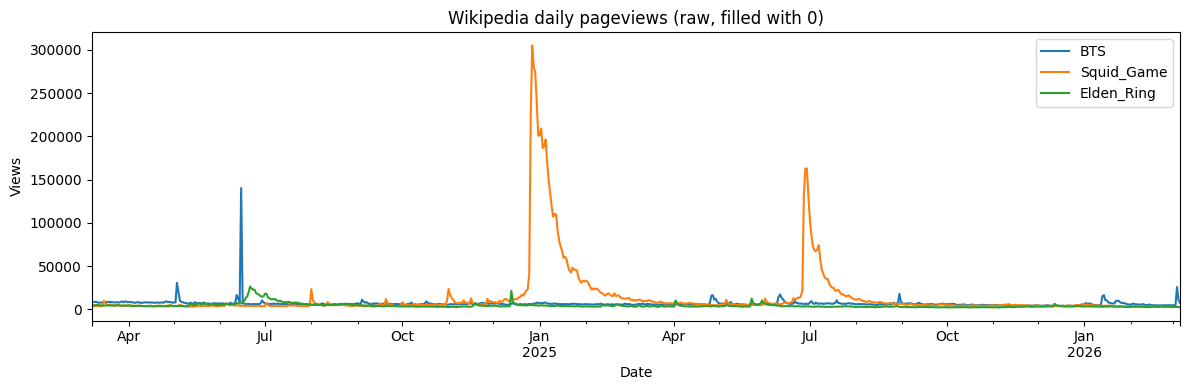

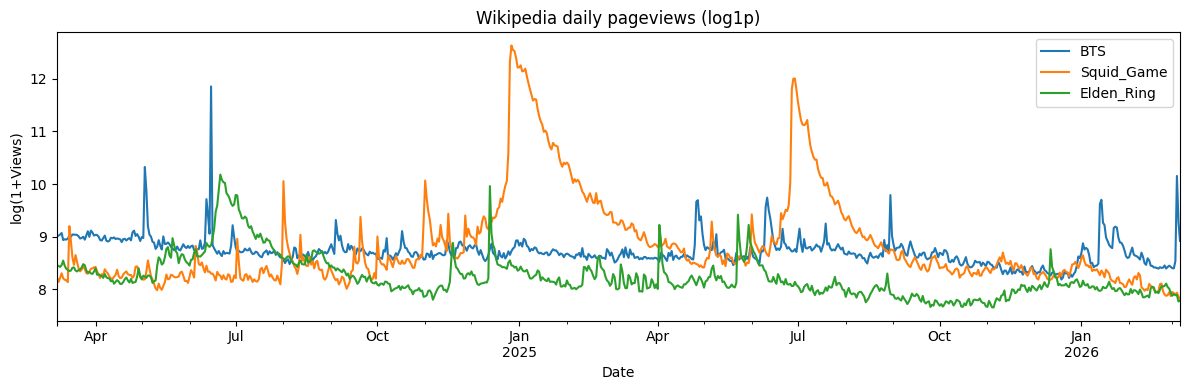

In [ ]:
df_zero.plot(title='Wikipedia daily pageviews (raw, filled with 0)')
plt.xlabel('Date'); plt.ylabel('Views'); plt.tight_layout(); plt.show()

df_log.plot(title='Wikipedia daily pageviews (log1p)')
plt.xlabel('Date'); plt.ylabel('log(1+Views)'); plt.tight_layout(); plt.show()


### 🔎 출력 해석 포인트 (시각화 해석)
- 원 단위(조회수)는 스파이크가 매우 커서 다른 구간이 눌려 보일 수 있습니다.
- 로그 변환은 비교(상대 변화)를 보기 좋게 만들어 줍니다.
- 특정 이벤트가 있었던 날짜에 스파이크가 나타나며, 이는 이상치/변화점 논의로 연결됩니다.

### ✅ Comprehension Check (과제형)
**빈칸 채우기**

- Q1. 로그 변환을 하면 큰 스파이크가 (_____)되고, 나머지 구간이 더 (_____) 보인다.
- Q2. 스파이크는 이벤트 또는 (_____) 가능성을 시사한다.
- Q3. 관심도 데이터는 주가보다 (_____)가 더 두드러지는 경우가 많다.

<details>
<summary>정답 예시(펼치기)</summary>

- A1. 완화
- A2. 잘
- A3. 이상치(outlier)
- A4. 이벤트 효과

</details>


## 6) STL 분해(Trend/Seasonal/Residual) — log(1+views) 기준


> **학습목표 (6) STL)**
>
- Trend/Seasonal/Residual 성분을 분해해 구조를 진단한다.
- 관심도 데이터에서 ‘계절성’이 약하거나 불안정할 수 있음을 이해한다.
- Residual의 스파이크를 이상치/이벤트로 해석한다.


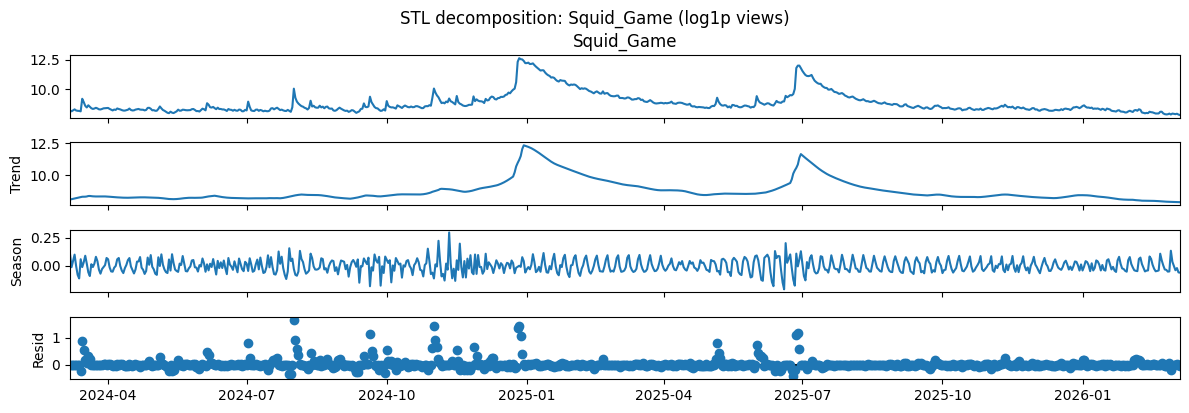

In [ ]:
series_name = 'Squid_Game'  # 바꿔서 실험해보세요: BTS, Elden_Ring
y = df_log[series_name].dropna()

# 일별 데이터에서 주간 패턴(7)을 가정하는 예시. 데이터 성격에 따라 7/14/365 등 실험 가능
stl = STL(y, period=7, robust=True)
res = stl.fit()
res.plot(); plt.suptitle(f'STL decomposition: {series_name} (log1p views)', y=1.02); plt.show()


### 🔎 출력 해석 포인트 (STL 해석)
- Trend는 장기 관심도의 레벨 변화, Seasonal은 반복 패턴(주간 등), Residual은 설명되지 않는 변동입니다.
- robust=True는 이상치의 영향을 줄여 분해를 안정화합니다.
- period는 ‘반복 길이’이며, 데이터에 따라 다릅니다(주간=7이 항상 정답은 아님).

### ✅ Comprehension Check (과제형)
**빈칸 채우기**

- Q1. STL의 기본 관계는 관측 ≈ (_____) + (_____) + (_____) 이다.
- Q2. robust STL은 (_____)의 영향을 줄이는 목적이 있다.
- Q3. 주간 패턴을 가정하면 period는 (_____)로 둔다.

<details>
<summary>정답 예시(펼치기)</summary>

- A1. Trend
- A2. Seasonal
- A3. Residual
- A4. 이상치(outlier)
- A5. 7

</details>


## 7) ACF/PACF & 정상성(ADF/KPSS) 진단 — log(1+views)


> **학습목표 (7) 진단)**
>
- ACF/PACF에서 주기성/자기상관 구조를 읽는다.
- ADF(단위근 H0)와 KPSS(정상성 H0)의 차이를 정확히 말할 수 있다.
- 관심도 데이터의 비정상성을 차분/변환으로 완화하는 아이디어를 제시한다.


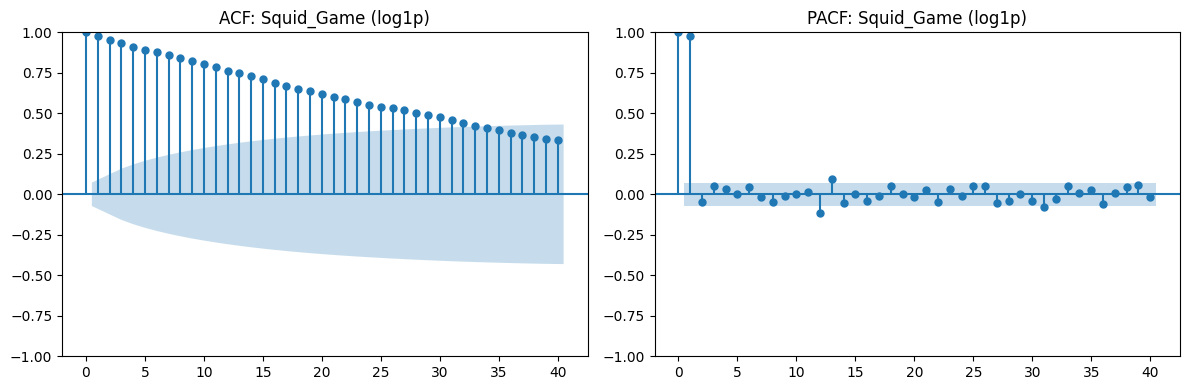

ADF p-value (H0=unit root): 0.0834
KPSS p-value (H0=stationary): 0.0453


In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss

def adf_kpss(y: pd.Series, kpss_reg='c'):
    y = y.dropna()
    adf_p = adfuller(y, autolag='AIC')[1]
    kpss_p = kpss(y, regression=kpss_reg, nlags='auto')[1]
    return adf_p, kpss_p

fig, ax = plt.subplots(1,2, figsize=(12,4))
plot_acf(y, lags=40, ax=ax[0]); ax[0].set_title(f'ACF: {series_name} (log1p)')
plot_pacf(y, lags=40, ax=ax[1], method='ywm'); ax[1].set_title(f'PACF: {series_name} (log1p)')
plt.tight_layout(); plt.show()

adf_p, kpss_p = adf_kpss(y)
print(f'ADF p-value (H0=unit root): {adf_p:.4f}')
print(f'KPSS p-value (H0=stationary): {kpss_p:.4f}')


### 🔎 출력 해석 포인트 (진단 결과 읽기)
- ACF가 오래 남으면(느린 감쇠) 비정상/추세 가능성이 있습니다.
- ADF의 H0는 단위근(비정상), KPSS의 H0는 정상성입니다(서로 반대).
- 관심도는 이벤트로 구조 변화가 있어 ‘완벽한 정상성’이 어려운 데이터일 수 있습니다.

### ✅ Comprehension Check (과제형)
**빈칸 채우기**

- Q1. ADF의 귀무가설(H0)은 단위근 (_____)이다.
- Q2. KPSS의 귀무가설(H0)은 (_____)이다.
- Q3. ACF가 느리게 감쇠하면 비정상 또는 (_____) 가능성을 의심한다.

<details>
<summary>정답 예시(펼치기)</summary>

- A1. 존재(비정상)
- A2. 정상성(stationary)
- A3. 추세(trend)

</details>


## 8) 간단 예측 예제: Seasonal Naïve(주간) + 평가
관심도 데이터는 이벤트 스파이크가 커서 복잡한 모델보다 **베이스라인 비교**가 학습에 더 중요합니다.
- Seasonal Naïve(7일 주기): `ŷ_t = y_{t-7}`


Seasonal Naive (h=7) | RMSE=0.1200, MAE=0.0965  (log1p scale)


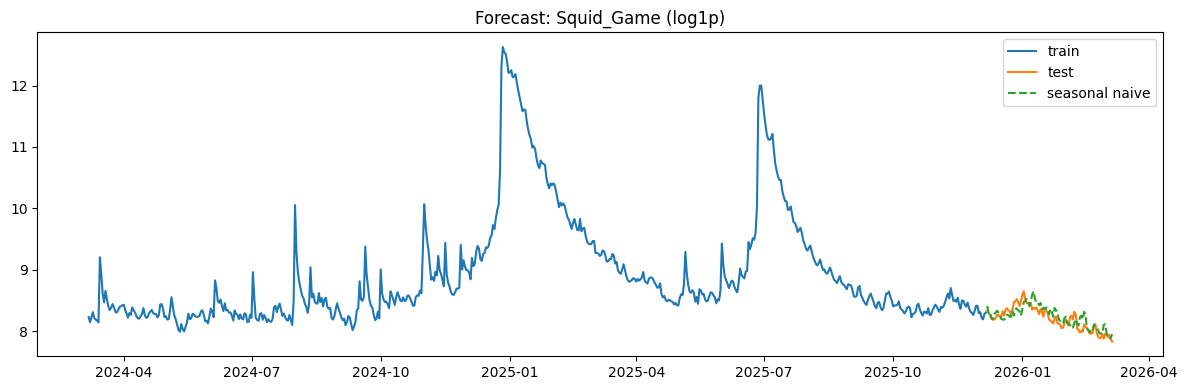

In [ ]:
import math
from sklearn.metrics import mean_absolute_error, mean_squared_error

h = 7  # season length
y2 = y.copy()

# train/test split (마지막 90일을 테스트)
test_n = 90
y_train = y2.iloc[:-test_n]
y_test  = y2.iloc[-test_n:]

# Seasonal naive forecast
y_pred = y_test.copy()*np.nan
for i, t in enumerate(y_test.index):
    t_lag = t - pd.Timedelta(days=h)
    if t_lag in y2.index:
        y_pred.loc[t] = y2.loc[t_lag]

rmse = math.sqrt(mean_squared_error(y_test.dropna(), y_pred.dropna()))
mae  = mean_absolute_error(y_test.dropna(), y_pred.dropna())
print(f'Seasonal Naive (h={h}) | RMSE={rmse:.4f}, MAE={mae:.4f}  (log1p scale)')

plt.figure(figsize=(12,4))
plt.plot(y_train.index, y_train, label='train')
plt.plot(y_test.index, y_test, label='test')
plt.plot(y_pred.index, y_pred, label='seasonal naive', linestyle='--')
plt.title(f'Forecast: {series_name} (log1p)')
plt.legend(); plt.tight_layout(); plt.show()

### 🔎 출력 해석 포인트 (예측 해석)
- Seasonal Naïve는 ‘지난주 오늘’ 값을 그대로 쓰는 매우 강력한 기준선입니다.
- 관심도 데이터에서 예측은 이벤트 스파이크 때문에 어렵고, 베이스라인 대비 개선이 핵심입니다.
- 평가 지표는 로그 스케일이므로, 필요 시 expm1로 원 단위로 복원해 해석할 수 있습니다.

### ✅ Comprehension Check (과제형)
**빈칸 채우기**

- Q1. Seasonal Naïve(h=7)는 ŷ_t = y_{t-(_____) } 형태다.
- Q2. 로그 스케일 예측을 원 단위로 되돌릴 때는 (_____)를 사용한다.
- Q3. 이 데이터에서 예측이 어려운 이유 중 하나는 이벤트로 인한 (_____) 때문이다.

<details>
<summary>정답 예시(펼치기)</summary>

- A1. 7
- A2. expm1
- A3. 스파이크/이상치

</details>


## ✅ 마무리 (요약 3줄)
1) Wikimedia Pageviews는 **가입/키 없이** 콘텐츠 관심도 시계열을 만들 수 있는 좋은 교육용 데이터입니다.
2) 관심도는 이벤트 스파이크가 커서 로그 변환·STL·ACF/검정으로 구조를 먼저 진단하는 것이 중요합니다.
3) 예측은 Seasonal Naïve 같은 강력한 베이스라인부터 비교하며, 잔차/오차 해석으로 다음 모델(ARIMA/ML/DL)로 확장합니다.

### ➡️ 다음 노트북 연결
- 다음 단계에서는 (1) 차분/변환으로 정상성을 더 확보한 뒤, (2) ARIMA/SARIMA 후보를 세워 예측 성능을 비교하거나,
- (3) 외생변수(예: Google Trends, 뉴스 이벤트 더미)를 추가해 ‘이벤트 설명형 모델’로 확장할 수 있습니다.
